In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive
time: 33.9 s (started: 2026-01-06 18:28:37 +00:00)


In [ ]:

import pandas as pd
import numpy as np
import csv
import pickle
import copy
import re
import random
import matplotlib.pyplot as plt
import itertools
import json
import openai
import time

!pip install ipython-autotime
%load_ext autotime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.0 MB/s eta 0:00:00
time: 321 µs (started: 2026-01-06 18:28:37 +00:00)


In [ ]:
!rm -rf LLM4BEAR
!git clone --depth 1 --filter=blob:none --sparse https://github.com/anon5159753/LLM4BEAR.git
!cd LLM4BEAR && git sparse-checkout set "BundleRec Data"
!cd LLM4BEAR && git sparse-checkout add "2_Bundle Refinement"



Cloning into 'LLM4BEAR'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 22 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 8.80 KiB | 8.80 MiB/s, done.
remote: Enumerating objects: 1, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 1 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (1/1), 66 bytes | 66.00 KiB/s, done.
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 82 (delta 16), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 45.90 MiB | 9.95 MiB/s, done.
Resolving deltas: 100% (16/16), done.
Updating files: 100% (83/83), done.
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 43

In [ ]:
clothing_bundles_items = pd.read_pickle("/content/LLM4BEAR/BundleRec Data/clothing/bundle_list_items.pkl")

electronic_bundles_items = pd.read_pickle("/content/LLM4BEAR/BundleRec Data/electronic/bundle_list_items.pkl")

food_bundles_items = pd.read_pickle("/content/LLM4BEAR/BundleRec Data/food/bundle_list_items.pkl")

bundle_items_list = [clothing_bundles_items, electronic_bundles_items, food_bundles_items]

clothing_intent = pd.read_csv("/content/LLM4BEAR/BundleRec Data/clothing/bundle_intent.csv")

electronics_intent = pd.read_csv("/content/LLM4BEAR/BundleRec Data/electronic/bundle_intent.csv")

food_intent = pd.read_csv("/content/LLM4BEAR/BundleRec Data/food/bundle_intent.csv")

intents = [clothing_intent, electronics_intent, food_intent]

clothing_metadata = pd.read_csv("/content/LLM4BEAR/BundleRec Data/clothing/merged_metadata.csv")

electronic_metadata = pd.read_csv("/content/LLM4BEAR/BundleRec Data/electronic/merged_metadata.csv")

food_metadata = pd.read_csv("/content/LLM4BEAR/BundleRec Data/food/merged_metadata.csv")

metadata = [clothing_metadata, electronic_metadata, food_metadata]

clothing_user_session = pd.read_csv("/content/LLM4BEAR/BundleRec Data/clothing/user_session.csv")

clothing_user_item = pd.read_csv("/content/LLM4BEAR/BundleRec Data/clothing/user_item.csv")

clothing_user_bundle = pd.read_csv("/content/LLM4BEAR/BundleRec Data/clothing/user_bundle.csv")

clothing_session_bundle = pd.read_csv("/content/LLM4BEAR/BundleRec Data/clothing/session_bundle.csv")

clothing_session_item = pd.read_csv("/content/LLM4BEAR/BundleRec Data/clothing/session_item.csv")

clothing_item_names = pd.read_csv("/content/LLM4BEAR/BundleRec Data/clothing/item_titles.csv")

electronic_user_session = pd.read_csv("/content/LLM4BEAR/BundleRec Data/electronic/user_session.csv")

electronic_user_item = pd.read_csv("/content/LLM4BEAR/BundleRec Data/electronic/user_item.csv")

electronic_user_bundle = pd.read_csv("/content/LLM4BEAR/BundleRec Data/electronic/user_bundle.csv")

electronic_session_bundle = pd.read_csv("/content/LLM4BEAR/BundleRec Data/electronic/session_bundle.csv")

electronic_session_item = pd.read_csv("/content/LLM4BEAR/BundleRec Data/electronic/session_item.csv")

electronic_item_names = pd.read_csv("/content/LLM4BEAR/BundleRec Data/electronic/item_titles.csv")

food_user_session = pd.read_csv("/content/LLM4BEAR/BundleRec Data/food/user_session.csv")

food_user_item = pd.read_csv("/content/LLM4BEAR/BundleRec Data/food/user_item.csv")

food_user_bundle = pd.read_csv("/content/LLM4BEAR/BundleRec Data/food/user_bundle.csv")

food_session_bundle = pd.read_csv("/content/LLM4BEAR/BundleRec Data/food/session_bundle.csv")

food_session_item = pd.read_csv("/content/LLM4BEAR/BundleRec Data/food/session_item.csv")

food_item_names = pd.read_csv("/content/LLM4BEAR/BundleRec Data/food/item_titles.csv")

user_session = [clothing_user_session, electronic_user_session, food_user_session]

user_item = [clothing_user_item, electronic_user_item, food_user_item]

user_bundle = [clothing_user_bundle, electronic_user_bundle, food_user_bundle]

session_bundle = [clothing_session_bundle, electronic_session_bundle, food_session_bundle]

session_item = [clothing_session_item, electronic_session_item, food_session_item]

item_names = [clothing_item_names, electronic_item_names, food_item_names]

time: 185 ms (started: 2026-01-06 18:38:10 +00:00)


In [ ]:
domain = ["electronic", "clothing", "food",
                 "electronic", "clothing", "food",
                 "electronic", "clothing", "food",
                 "electronic", "clothing", "food",
                 "electronic", "clothing", "food",
                 "electronic", "clothing", "food"
                 ]

runs = [
    "complete_electronic_session_expanded_run",
    "complete_clothing_session_expanded_run",
    "complete_food_session_expanded_run",
    "complete_electronic_session_only_run",
    "complete_clothing_session_only_run",
    "complete_food_session_only_run",
    "complete_electronic_expanded_only_run",
    "complete_clothing_expanded_only_run",
    "complete_food_expanded_only_run",
    "complete_electronic_no_enrichment_run",
    "complete_clothing_no_enrichment_run",
    "complete_food_no_enrichment_run",
    "complete_electronic_no_evaluator_help_run",
    "complete_clothing_no_evaluator_help_run",
    "complete_food_no_evaluator_help_run",
    "complete_electronic_no_graph_help_run",
    "complete_clothing_no_graph_help_run",
    "complete_food_no_graph_help_run"
]

time: 1.15 ms (started: 2026-01-06 18:42:39 +00:00)


In [ ]:

def get_max_scores(given, min_scores, l):

    first_layer = given[0]

    first_min = min_scores[0]



    scores = [[] for _ in range(l)]

    min_guys = [[] for _ in range(l)]


    for i in range(l):
        for j in range(len(given)):

            scores[i].append(given[j][i])

            min_guys[i].append(min_scores[j][i])




    argmax = [np.argmax(scores[i]) for i in range(l)]

    argmax_for_min = [np.argmax(min_guys[i]) for i in range(l)]

    # print(first_layer)
    # print(given[-1])

    # print(first_min)
    # print(min_scores[-1])


    best_args = [[argmax[i]] for i in range(l)]
    best_scores = [[scores[i][argmax[i]]] for i in range(l)]

    best_min_args = [[argmax_for_min[i]] for i in range(l)]
    best_min_scores = [[min_guys[i][argmax_for_min[i]]] for i in range(l)]


    mean_scores = np.mean([best_scores[i][0] for i in range(l)])
    mean_min_scores = np.mean([best_min_scores[i][0] for i in range(l)])

    first_mean = np.mean(first_layer)
    first_min_mean = np.mean(first_min)

    print("First Layer Avg:", np.round(first_mean,2))
    print("Modification Avg:", np.round(mean_scores, 2))

    print("First Layer Min Avg:", np.round(first_min_mean,2))
    print("Modification Min Avg:", np.round(mean_min_scores, 2))

    return

time: 2.04 ms (started: 2026-01-06 18:36:20 +00:00)


# We see the No Graphs Workflow Perform the best, achieving high-quality bundle refinement whilst sacrificing the least amount of effective item representation.

In [ ]:

for i in range(len(runs)):

    # with open(f"/content/drive/MyDrive/Bundle_Refinement/historical_bundle_changes_{domain[i]}_{runs[i]}.pkl", "rb") as f:
    with open(f"/content/LLM4BEAR/2_Bundle Refinement/historic_bundle_refinement/historical_bundle_changes_{domain[i]}_{runs[i]}.pkl", "rb") as f:

        intents, bundle_items, bundle_indices, scores, min_scores, flags = pickle.load(f)

    print(runs[i])
    l = len(intents[0])
    print("LENGTH:", l)
    print("Num_iter:", len(intents))

    first_flags = flags[0]
    last_flags = flags[-1]


    start_bundles = bundle_items[0]
    end_bundles = bundle_items[-1]

    start_len = [len(i) for i in start_bundles]
    end_len = [len(i) for i in end_bundles]

    mean_start_len = np.mean(start_len)
    mean_end_len = np.mean(end_len)

    print("start len:", mean_start_len)
    print("end len:", mean_end_len)


    # print(first_flags)
    # print(last_flags)

    print(l-sum(first_flags))
    print(l-sum(last_flags))
    print(domain[i])
    get_max_scores(scores, min_scores, l)


    print()
    print()
    print()


complete_electronic_session_expanded_run
LENGTH: 1750
Num_iter: 21
start len: 3.5228571428571427
end len: 2.802857142857143
403
1673
electronic
First Layer Avg: 2.98
Modification Avg: 4.62
First Layer Min Avg: 2.4
Modification Min Avg: 4.39



complete_clothing_session_expanded_run
LENGTH: 1910
Num_iter: 21
start len: 3.312041884816754
end len: 2.66282722513089
793
1810
clothing
First Layer Avg: 3.35
Modification Avg: 4.43
First Layer Min Avg: 2.66
Modification Min Avg: 4.09



complete_food_session_expanded_run
LENGTH: 1784
Num_iter: 21
start len: 3.5846412556053813
end len: 3.234865470852018
421
1757
food
First Layer Avg: 3.12
Modification Avg: 4.57
First Layer Min Avg: 2.41
Modification Min Avg: 4.32



complete_electronic_session_only_run
LENGTH: 1750
Num_iter: 21
start len: 3.5228571428571427
end len: 2.553714285714286
398
1180
electronic
First Layer Avg: 2.98
Modification Avg: 4.15
First Layer Min Avg: 2.4
Modification Min Avg: 3.72



complete_clothing_session_only_run
LENGTH: 1

In [ ]:

for i in range(len(runs)):

    # with open(f"/content/drive/MyDrive/Bundle_Refinement/historical_bundle_changes_{domain[i]}_{runs[i]}.pkl", "rb") as f:
    with open(f"/content/LLM4BEAR/2_Bundle Refinement/historic_bundle_refinement/historical_bundle_changes_{domain[i]}_{runs[i]}.pkl", "rb") as f:
        intents, bundle_items, bundle_indices, scores, min_scores, flags = pickle.load(f)
    print(runs[i])
    l = len(intents[0])
    print("LENGTH:", l)
    print("Num_iter:", len(intents))

    first_flags = flags[0]
    last_flags = flags[-1]

    regular_flags = [True for _ in range(l)]
    for i in range(l):
        if first_flags[i] == False:
            regular_flags[i] = False
        if last_flags[i] == True:
            regular_flags[i] = False


    mods_length = [0 for _ in range(l)]

    for i in range(l):
        count = 0
        if regular_flags[i] == True:


            for j in range(len(intents)):
                if flags[j][i] == True:
                    count += 1
        mods_length[i] += count





    print("Successful Modifications:", np.round(sum(regular_flags), 2))
    print("Avg Number of Modifications:", np.round(sum(mods_length)/sum(regular_flags), 2))

    print()
    print()
    print()

complete_electronic_session_expanded_run
LENGTH: 1750
Num_iter: 21
Successful Modifications: 1270
Avg Number of Modifications: 4.06



complete_clothing_session_expanded_run
LENGTH: 1910
Num_iter: 21
Successful Modifications: 1017
Avg Number of Modifications: 3.92



complete_food_session_expanded_run
LENGTH: 1784
Num_iter: 21
Successful Modifications: 1336
Avg Number of Modifications: 4.11



complete_electronic_session_only_run
LENGTH: 1750
Num_iter: 21
Successful Modifications: 782
Avg Number of Modifications: 4.17



complete_clothing_session_only_run
LENGTH: 1910
Num_iter: 21
Successful Modifications: 746
Avg Number of Modifications: 3.43



complete_food_session_only_run
LENGTH: 1784
Num_iter: 21
Successful Modifications: 870
Avg Number of Modifications: 4.4



complete_electronic_expanded_only_run
LENGTH: 1750
Num_iter: 21
Successful Modifications: 1270
Avg Number of Modifications: 4.06



complete_clothing_expanded_only_run
LENGTH: 1910
Num_iter: 21
Successful Modifications: 10

complete_electronic_session_expanded_run
LENGTH: 1750
Num_iter: 21


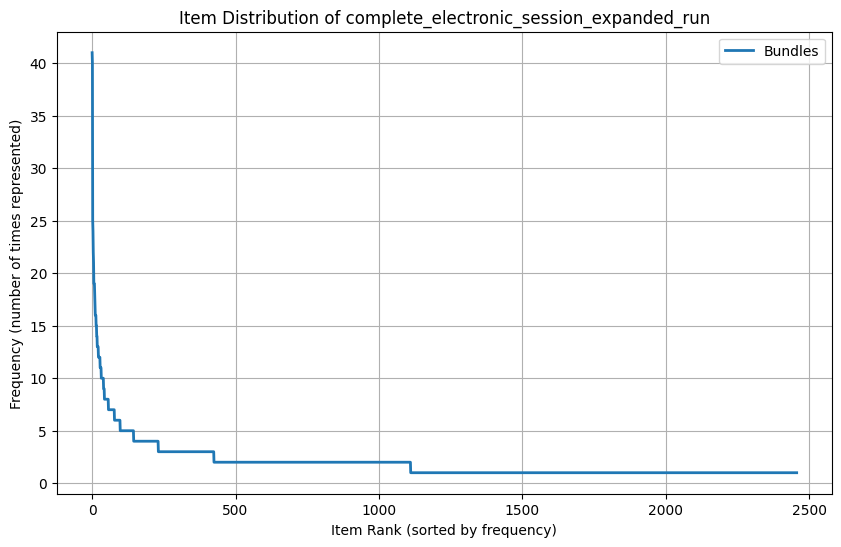

complete_clothing_session_expanded_run
LENGTH: 1910
Num_iter: 21


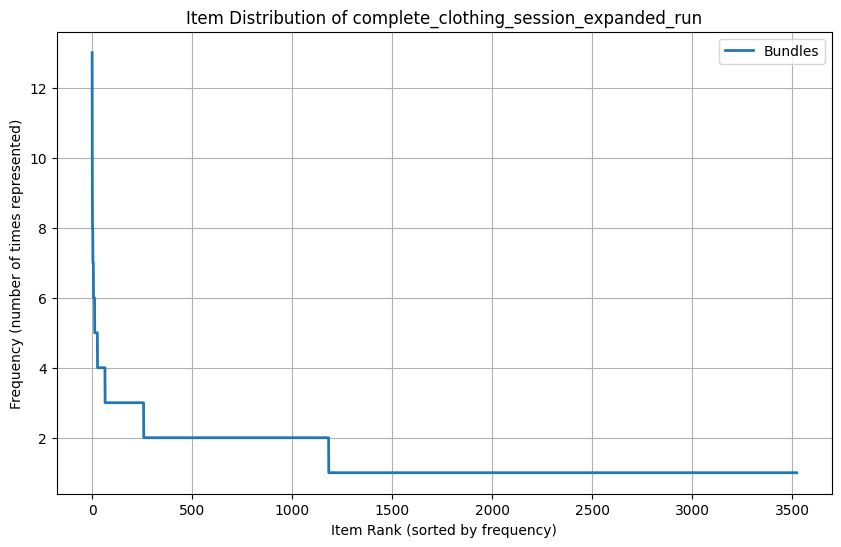

complete_food_session_expanded_run
LENGTH: 1784
Num_iter: 21


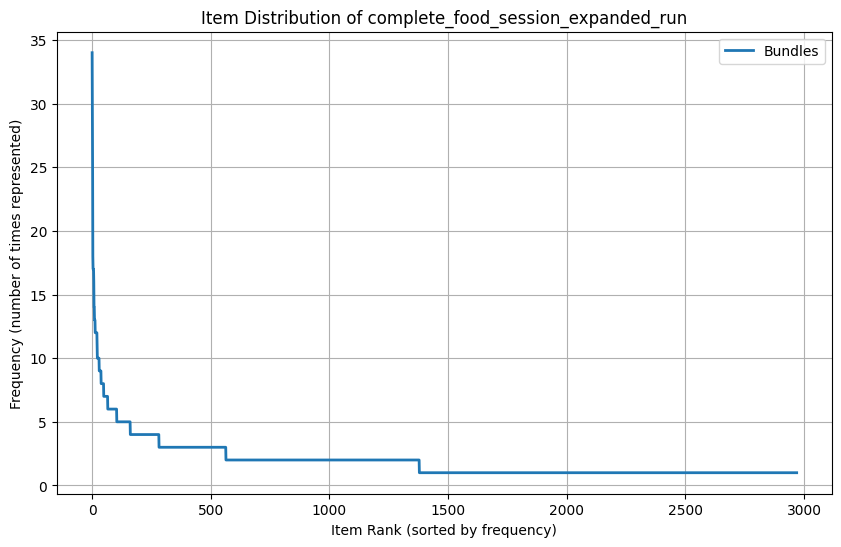

complete_electronic_session_only_run
LENGTH: 1750
Num_iter: 21


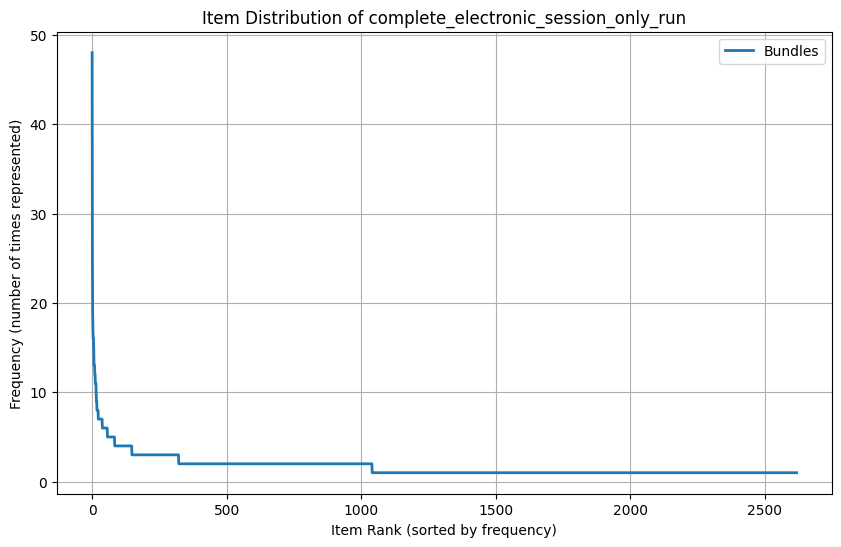

complete_clothing_session_only_run
LENGTH: 1910
Num_iter: 21


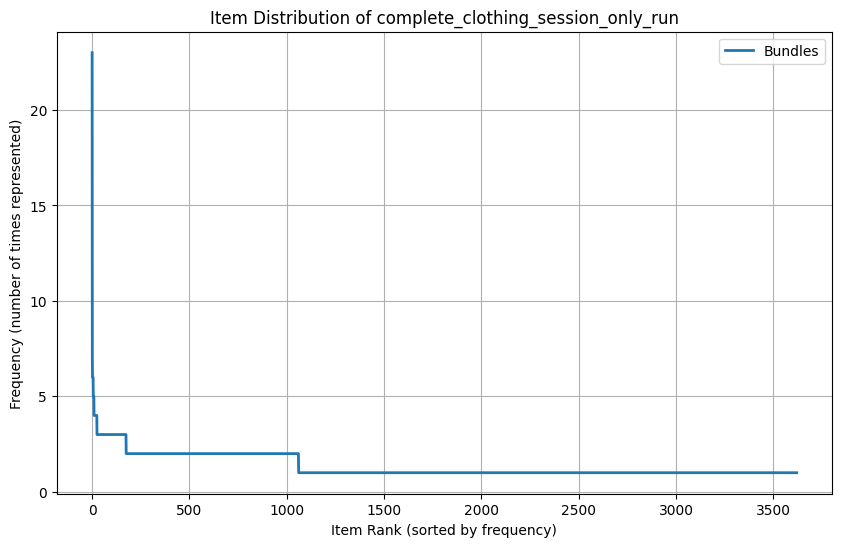

complete_food_session_only_run
LENGTH: 1784
Num_iter: 21


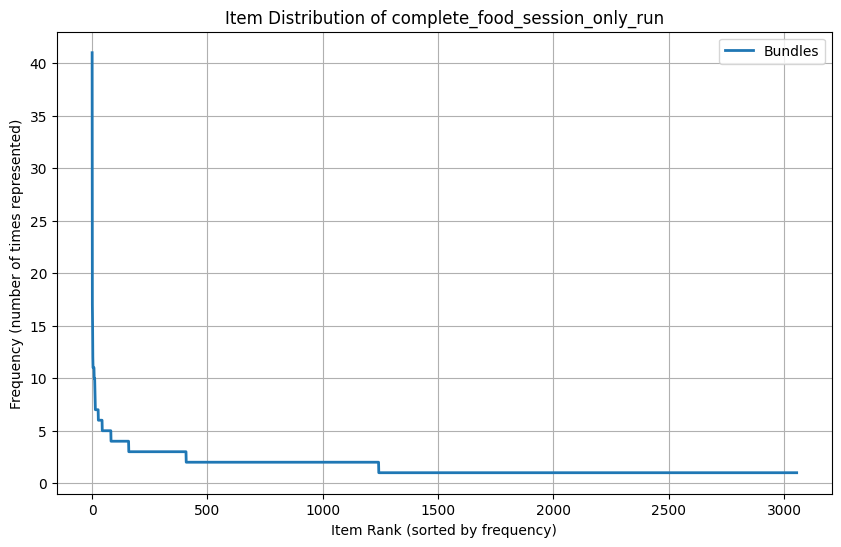

complete_electronic_expanded_only_run
LENGTH: 1750
Num_iter: 21


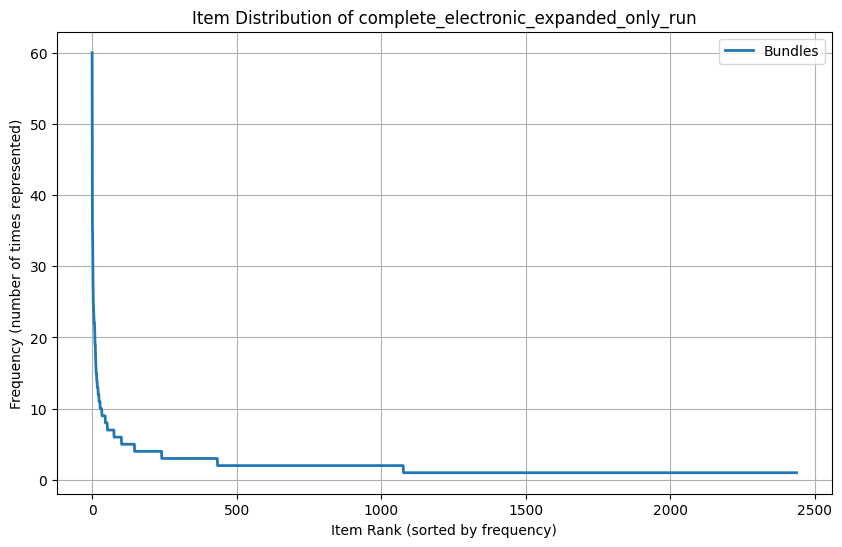

complete_clothing_expanded_only_run
LENGTH: 1910
Num_iter: 21


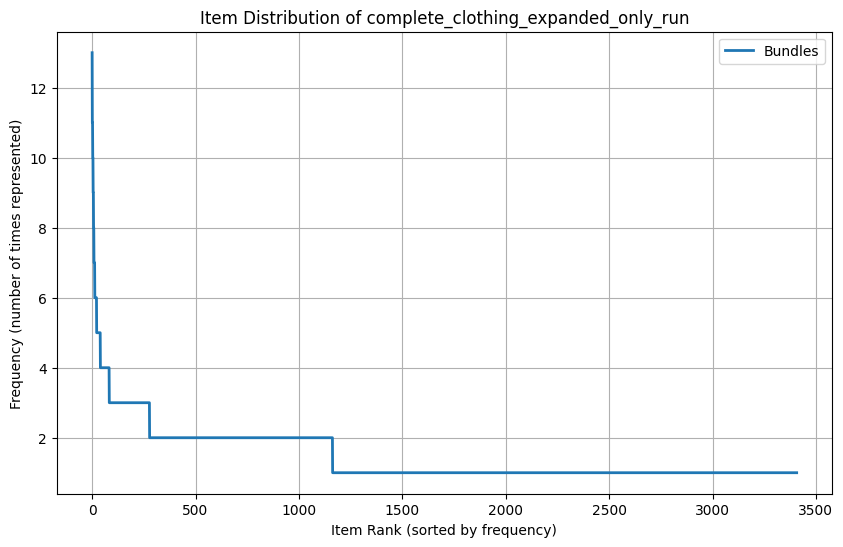

complete_food_expanded_only_run
LENGTH: 1784
Num_iter: 21


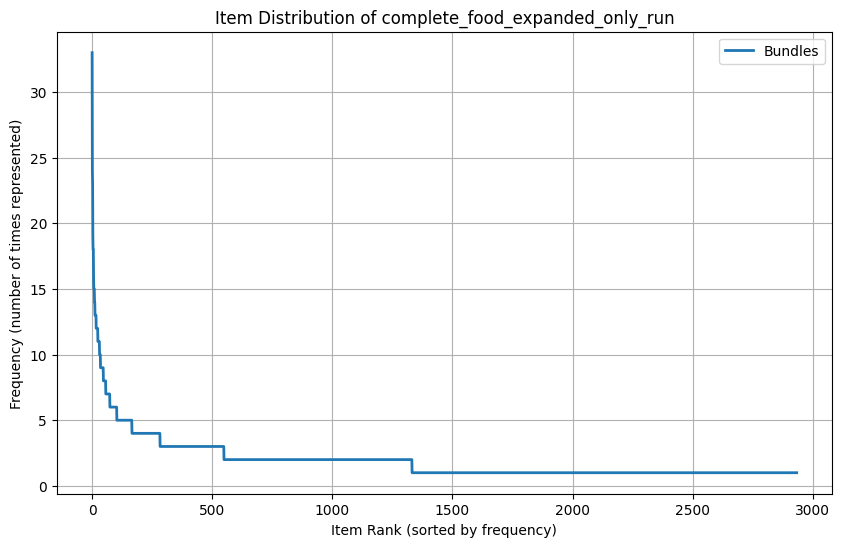

complete_electronic_no_enrichment_run
LENGTH: 1750
Num_iter: 21


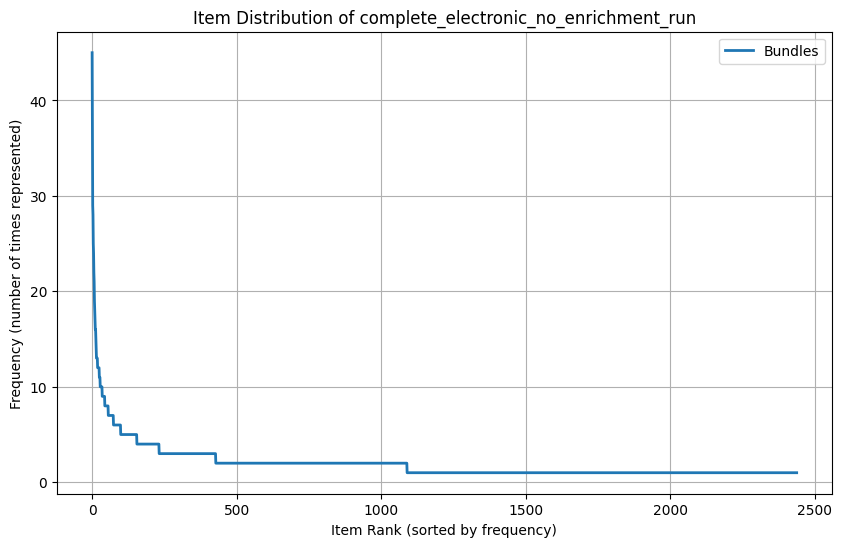

complete_clothing_no_enrichment_run
LENGTH: 1910
Num_iter: 21


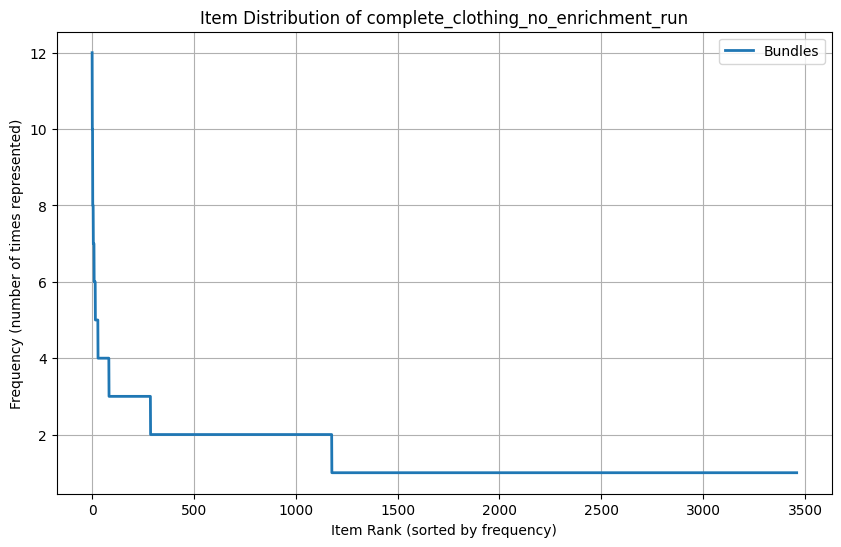

complete_food_no_enrichment_run
LENGTH: 1784
Num_iter: 21


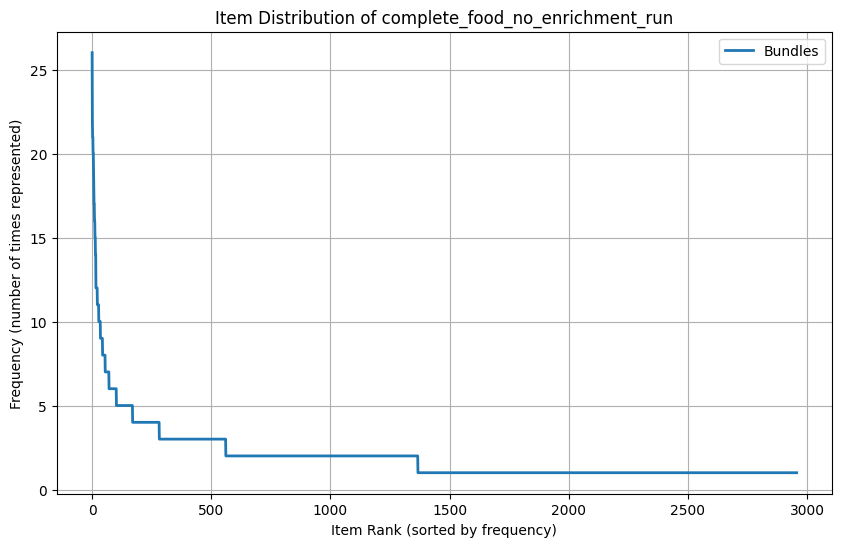

complete_electronic_no_evaluator_help_run
LENGTH: 1750
Num_iter: 11


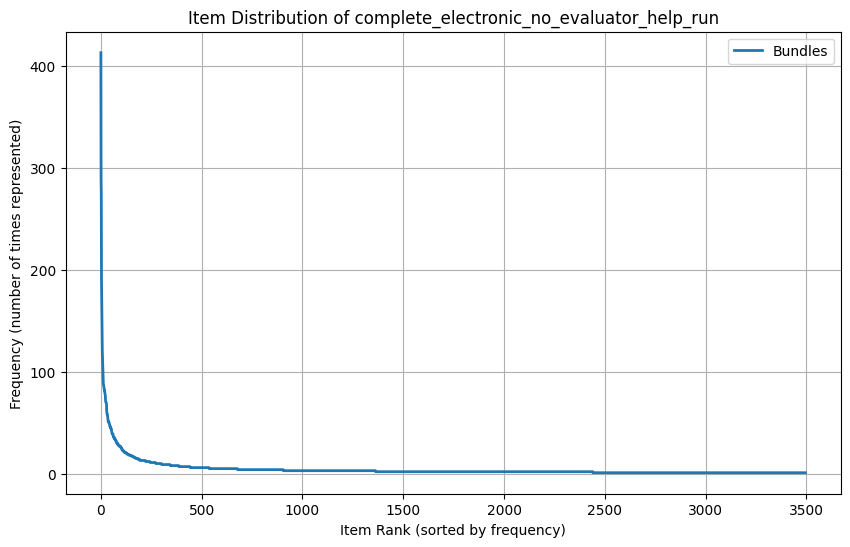

complete_clothing_no_evaluator_help_run
LENGTH: 1910
Num_iter: 11


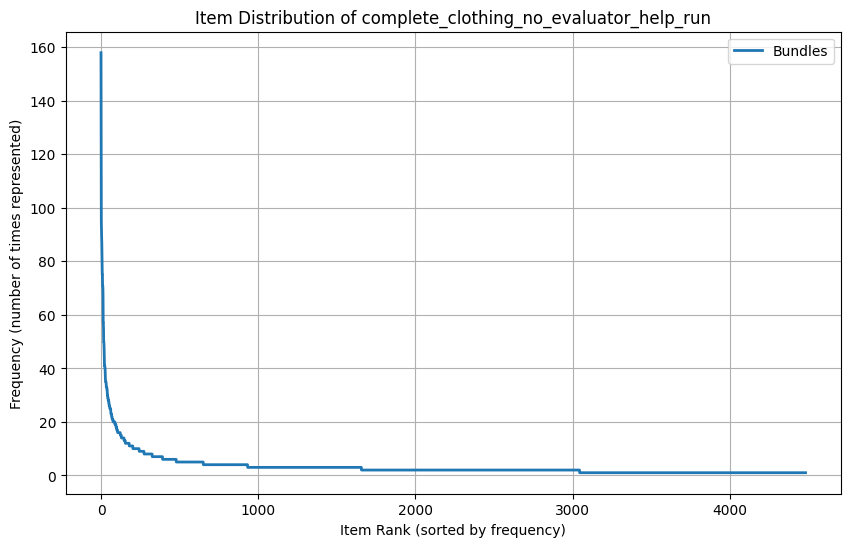

complete_food_no_evaluator_help_run
LENGTH: 1784
Num_iter: 11


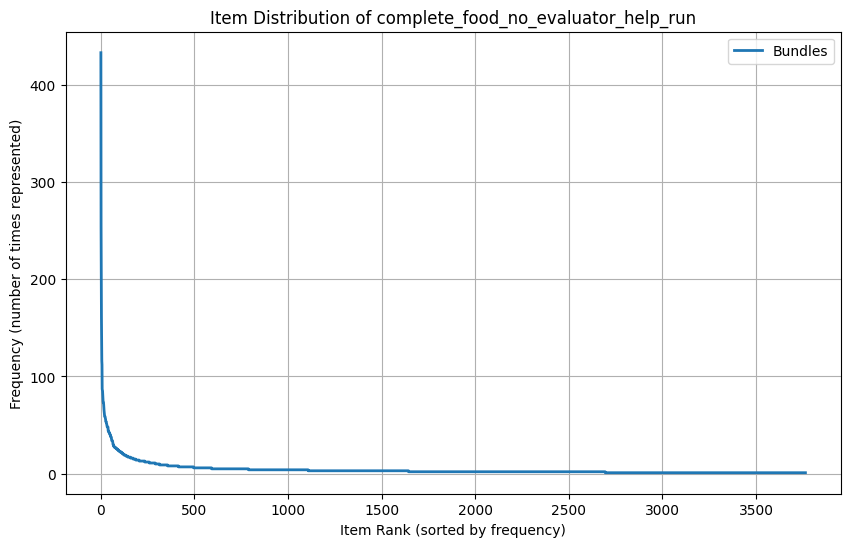

complete_electronic_no_graph_help_run
LENGTH: 1750
Num_iter: 21


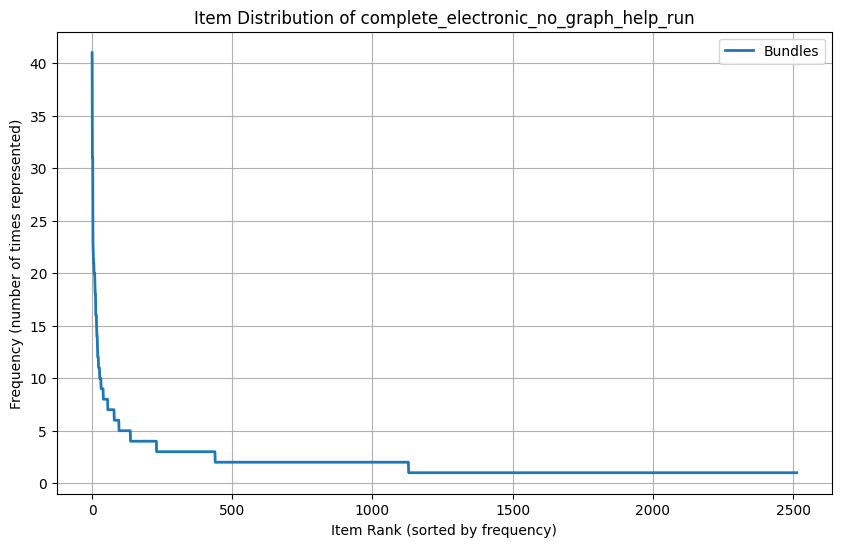

complete_clothing_no_graph_help_run
LENGTH: 1910
Num_iter: 21


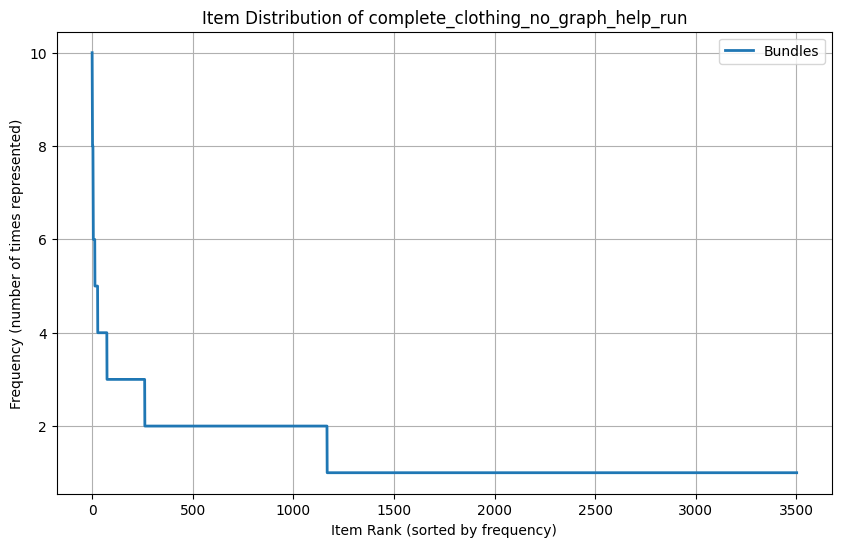

complete_food_no_graph_help_run
LENGTH: 1784
Num_iter: 21


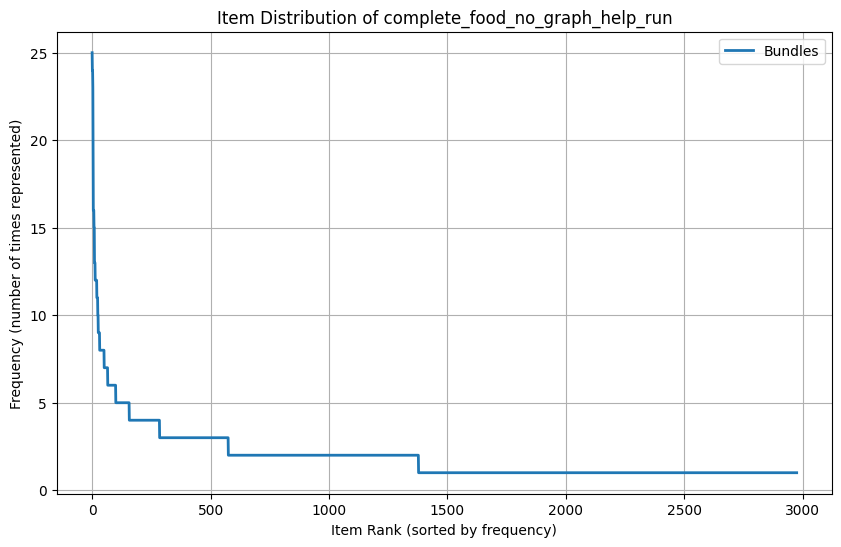

time: 8.61 s (started: 2026-01-06 18:46:48 +00:00)


In [23]:
import pickle
from collections import Counter

for idx in range(len(runs)):
    # with open(f"/content/drive/MyDrive/Bundle_Refinement/historical_bundle_changes_{domain[i]}_{runs[i]}.pkl", "rb") as f:
    with open(f"/content/LLM4BEAR/2_Bundle Refinement/historic_bundle_refinement/historical_bundle_changes_{domain[idx]}_{runs[idx]}.pkl", "rb") as f:
        intents, bundle_items, bundle_indices, scores, min_scores, flags = pickle.load(f)

    print(runs[idx])
    l = len(intents[0])
    print("LENGTH:", l)
    print("Num_iter:", len(intents))

    # Initial and final bundles
    initial_bundles = bundle_items[0]
    final_bundles = bundle_items[-1]

    # Flatten bundles
    initial_slob = [j for i in initial_bundles for j in i]
    final_slob = [j for i in final_bundles for j in i]

    # Choose the metadata for the domain
    if domain[idx] == "electronic":
        metadata = electronic_metadata
    elif domain[idx] == "clothing":
        metadata = clothing_metadata
    elif domain[idx] == "food":
        metadata = food_metadata
    else:
        print("Unknown domain:", domain[idx])
        continue

    # Count frequencies
    initial_counts = Counter(initial_slob)
    final_counts = Counter(final_slob)

    # Count frequencies
    initial_counts = Counter(initial_slob)
    final_counts = Counter(final_slob)

    # Sort counts descending
    initial_freqs = sorted(initial_counts.values(), reverse=True)
    final_freqs = sorted(final_counts.values(), reverse=True)

    # Plot distributions
    plt.figure(figsize=(10,6))
    plt.plot(final_freqs, label='Bundles', linewidth=2)
    plt.xlabel("Item Rank (sorted by frequency)")
    plt.ylabel("Frequency (number of times represented)")
    plt.title(f"Item Distribution of {runs[idx]}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [24]:
import pickle
from collections import Counter
import numpy as np

def gini(x):
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

for idx in range(len(runs)):
    # with open(f"/content/drive/MyDrive/Bundle_Refinement/historical_bundle_changes_{domain[i]}_{runs[i]}.pkl", "rb") as f:
    with open(f"/content/LLM4BEAR/2_Bundle Refinement/historic_bundle_refinement/historical_bundle_changes_{domain[idx]}_{runs[idx]}.pkl", "rb") as f:
        intents, bundle_items, bundle_indices, scores, min_scores, flags = pickle.load(f)

    print(runs[idx])
    l = len(intents[0])
    print("LENGTH:", l)
    print("Num_iter:", len(intents))

    # Initial and final bundles
    initial_bundles = bundle_items[0]
    final_bundles = bundle_items[-1]

    # Flatten bundles
    initial_slob = [j for i in initial_bundles for j in i]
    final_slob = [j for i in final_bundles for j in i]

    # Choose metadata for the domain
    if domain[idx] == "electronic":
        metadata = electronic_metadata
    elif domain[idx] == "clothing":
        metadata = clothing_metadata
    elif domain[idx] == "food":
        metadata = food_metadata
    else:
        print("Unknown domain:", domain[idx])
        continue

    # Count frequencies
    initial_counts = Counter(initial_slob)
    final_counts = Counter(final_slob)

    # Sort counts descending
    initial_freqs = sorted(initial_counts.values(), reverse=True)
    final_freqs = sorted(final_counts.values(), reverse=True)

    # -------------------------------
    # 📊 Statistical distribution metrics
    # -------------------------------
    def compute_stats(freqs):
        freqs = np.array(freqs)
        p = freqs / freqs.sum()
        entropy = -np.sum(p * np.log2(p))
        gini_coeff = gini(freqs)
        cv = np.std(freqs) / np.mean(freqs)
        return entropy, gini_coeff, cv

    entropy_i, gini_i, cv_i = compute_stats(initial_freqs)
    entropy_f, gini_f, cv_f = compute_stats(final_freqs)

    print("\n--- Distribution Metrics ---")
    print(f"Initial Entropy: {entropy_i:.3f}, Gini: {gini_i:.3f}, CV: {cv_i:.3f}")
    print(f"Final   Entropy: {entropy_f:.3f}, Gini: {gini_f:.3f}, CV: {cv_f:.3f}")
    print("=" * 60 + "\n")


complete_electronic_session_expanded_run
LENGTH: 1750
Num_iter: 21

--- Distribution Metrics ---
Initial Entropy: 11.453, Gini: 0.307, CV: 0.898
Final   Entropy: 10.794, Gini: 0.373, CV: 1.154

complete_clothing_session_expanded_run
LENGTH: 1910
Num_iter: 21

--- Distribution Metrics ---
Initial Entropy: 12.005, Gini: 0.203, CV: 0.454
Final   Entropy: 11.622, Gini: 0.225, CV: 0.539

complete_food_session_expanded_run
LENGTH: 1784
Num_iter: 21

--- Distribution Metrics ---
Initial Entropy: 11.627, Gini: 0.286, CV: 0.721
Final   Entropy: 11.161, Gini: 0.348, CV: 0.953

complete_electronic_session_only_run
LENGTH: 1750
Num_iter: 21

--- Distribution Metrics ---
Initial Entropy: 11.453, Gini: 0.307, CV: 0.898
Final   Entropy: 11.017, Gini: 0.309, CV: 0.997

complete_clothing_session_only_run
LENGTH: 1910
Num_iter: 21

--- Distribution Metrics ---
Initial Entropy: 12.005, Gini: 0.203, CV: 0.454
Final   Entropy: 11.686, Gini: 0.198, CV: 0.525

complete_food_session_only_run
LENGTH: 1784
Num_

In [25]:
import pickle
from collections import Counter
import numpy as np

def gini(x):
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

# Domain-specific metadata sizes
domain_sizes = {
    "electronic": len(electronic_metadata),
    "clothing": len(clothing_metadata),
    "food": len(food_metadata)
}

for idx in range(len(runs)):
    with open(f"/content/drive/My Drive/Bundle_Rec_datasets/historical_bundle_changes_{domain[idx]}_{runs[idx]}.pkl", "rb") as f:
        intents, bundle_items, bundle_indices, scores, min_scores, flags = pickle.load(f)

    print(runs[idx])
    l = len(intents[0])
    print("LENGTH:", l)
    print("Num_iter:", len(intents))

    # Initial and final bundles
    initial_bundles = bundle_items[0]
    final_bundles = bundle_items[-1]

    # Flatten bundles
    initial_slob = [j for i in initial_bundles for j in i]
    final_slob = [j for i in final_bundles for j in i]

    # Choose metadata for the domain
    dom = domain[idx]
    if dom not in domain_sizes:
        print("Unknown domain:", dom)
        continue

    total_items = domain_sizes[dom]

    # Count frequencies
    initial_counts = Counter(initial_slob)
    final_counts = Counter(final_slob)

    # Sort counts descending
    initial_freqs = sorted(initial_counts.values(), reverse=True)
    final_freqs = sorted(final_counts.values(), reverse=True)

    # -------------------------------
    # 📊 Statistical distribution metrics
    # -------------------------------
    def compute_stats(freqs):
        freqs = np.array(freqs)
        p = freqs / freqs.sum()
        entropy = -np.sum(p * np.log2(p))
        gini_coeff = gini(freqs)
        cv = np.std(freqs) / np.mean(freqs)
        return entropy, gini_coeff, cv

    entropy_i, gini_i, cv_i = compute_stats(initial_freqs)
    entropy_f, gini_f, cv_f = compute_stats(final_freqs)

    # -------------------------------
    # 🧮 Coverage metrics
    # -------------------------------
    unique_initial = len(initial_counts)
    unique_final = len(final_counts)

    coverage_i = (unique_initial / total_items) * 100
    coverage_f = (unique_final / total_items) * 100

    # print("\n--- Distribution Metrics ---")
    # print(f"Initial Entropy: {entropy_i:.3f}, Gini: {gini_i:.3f}, CV: {cv_i:.3f}")
    # print(f"Final   Entropy: {entropy_f:.3f}, Gini: {gini_f:.3f}, CV: {cv_f:.3f}")

    # print("\n--- Coverage Metrics ---")
    # print(f"Initial Unique Items: {unique_initial}/{total_items} ({coverage_i:.2f}%)")
    print(f"Final   Unique Items: {unique_final}/{total_items} ({coverage_f:.2f}%)")

    print("=" * 60 + "\n")


complete_electronic_session_expanded_run
LENGTH: 1750
Num_iter: 21
Final   Unique Items: 2458/3499 (70.25%)

complete_clothing_session_expanded_run
LENGTH: 1910
Num_iter: 21
Final   Unique Items: 3523/4487 (78.52%)

complete_food_session_expanded_run
LENGTH: 1784
Num_iter: 21
Final   Unique Items: 2970/3767 (78.84%)

complete_electronic_session_only_run
LENGTH: 1750
Num_iter: 21
Final   Unique Items: 2620/3499 (74.88%)

complete_clothing_session_only_run
LENGTH: 1910
Num_iter: 21
Final   Unique Items: 3621/4487 (80.70%)

complete_food_session_only_run
LENGTH: 1784
Num_iter: 21
Final   Unique Items: 3056/3767 (81.13%)

complete_electronic_expanded_only_run
LENGTH: 1750
Num_iter: 21
Final   Unique Items: 2438/3499 (69.68%)

complete_clothing_expanded_only_run
LENGTH: 1910
Num_iter: 21
Final   Unique Items: 3408/4487 (75.95%)

complete_food_expanded_only_run
LENGTH: 1784
Num_iter: 21
Final   Unique Items: 2934/3767 (77.89%)

complete_electronic_no_enrichment_run
LENGTH: 1750
Num_iter: 21
